In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#sklearn preprocessing

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

#Regression model

from sklearn.linear_model import LinearRegression,Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.ensemble import VotingRegressor, StackingRegressor

#metrices

from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error

import warnings
warnings.filterwarnings("ignore")

In [5]:
df = pd.read_csv("./bangladesh_student_performance.csv")

In [6]:
df

,date,gender,age,address,famsize,Pstatus,M_Edu,F_Edu,M_Job,F_Job,relationship,smoker,tuition_fee,time_friends,ssc_result,hsc_result
0,29/04/2018,M,18,Rural,GT3,Together,3,2,At_home,Farmer,No,No,71672,4,4.22,3.72
1,29/04/2018,F,19,Rural,LE3,Apart,0,4,Other,Health,Yes,No,26085,5,3.47,2.62
2,29/04/2018,F,19,Rural,GT3,Together,0,3,Teacher,Services,No,No,40891,3,3.32,2.56
3,29/04/2018,F,19,Rural,LE3,Apart,2,3,At_home,Business,No,No,50600,2,4.57,4.17
4,29/04/2018,M,17,Rural,GT3,Together,1,1,At_home,Farmer,No,No,62458,2,4.50,3.94
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2013,29/04/2018,M,18,Urban,GT3,Together,2,2,Teacher,Health,No,No,108426,2,3.57,3.18
2014,29/04/2018,M,19,Urban,GT3,Together,0,3,Other,Teacher,Yes,No,100665,5,4.05,3.13
2015,29/04/2018,M,18,Urban,GT3,Together,3,2,Services,Farmer,Yes,No,92291,1,3.93,3.15
2016,29/04/2018,M,19,Rural,GT3,Together,0,2,At_home,Teacher,No,No,43926,3,3.34,2.83


### Y Data Profiling

In [7]:
!pip install ydata-profiling

   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   --------- ------------------------------ 1.8/8.0 MB 9.1 MB/s eta 0:00:01
   ---------------- ----------------------- 3.4/8.0 MB 7.7 MB/s eta 0:00:01
   ---------------------------- ----------- 5.8/8.0 MB 8.6 MB/s eta 0:00:01
   ---------------------------------------  7.9/8.0 MB 9.2 MB/s eta 0:00:01
   ---------------------------------------- 8.0/8.0 MB 8.9 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   --------------- ------------------------ 1.0/2.7 MB 12.5 MB/s eta 0:00:01
   ------------------------------ --------- 2.1/2.7 MB 5.1 MB/s eta 0:00:01
   ---------------------------------- ----- 2.4/2.7 MB 3.6 MB/s eta 0:00:01
   ---------------------------------------- 2.7/2.7 MB 3.9 MB/s eta 0:00:00
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   - -------------------------------------- 1.6/38.1 MB 7.6 MB/s eta 0:00:05
   ---- ----------------------

  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.

[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
from ydata_profiling import ProfileReport

profile = ProfileReport( df , title="Bangladesh Student performance prediction", explorative = True  )

profile.to_file("ydata.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 16/16 [00:00<00:00, 41.73it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [9]:
len(df.columns)

16

In [10]:
df.columns

Index(['date', 'gender', 'age', 'address', 'famsize', 'Pstatus', 'M_Edu',
       'F_Edu', 'M_Job', 'F_Job', 'relationship', 'smoker', 'tuition_fee',
       'time_friends', 'ssc_result', 'hsc_result'],
      dtype='object')

In [11]:
df.columns= [
    'date','st_gender','st_age','st_address',
    'st_fam_size','pstatus','m_edu','f_edu',
    'm_job','f_job','st_relationship',
    'smoker','tuition_fee','time_with_friends',
    'ssc_result','hsc_result'
]

In [12]:
df.columns

Index(['date', 'st_gender', 'st_age', 'st_address', 'st_fam_size', 'pstatus',
       'm_edu', 'f_edu', 'm_job', 'f_job', 'st_relationship', 'smoker',
       'tuition_fee', 'time_with_friends', 'ssc_result', 'hsc_result'],
      dtype='object')

In [13]:
if 'date' in df.columns:
  df.drop( columns = ['date'], inplace=True )

In [14]:
df.columns.size

15

## co-relation for numerical value

In [15]:
corr_target = df.select_dtypes(include=np.number).corr()['hsc_result'].sort_values(ascending=False)
print(corr_target)

hsc_result           1.000000
ssc_result           0.950178
m_edu                0.063776
f_edu                0.054811
tuition_fee          0.038068
st_age              -0.009857
time_with_friends   -0.156356
Name: hsc_result, dtype: float64


## Separate X and Y

In [16]:
X = df.drop('hsc_result', axis=1)
y = df['hsc_result']


In [17]:
numeric_features = X.select_dtypes(include = ['int64','float64']).columns
categorical_features = X.select_dtypes(include = ['object']).columns

In [18]:
numeric_features

Index(['st_age', 'm_edu', 'f_edu', 'tuition_fee', 'time_with_friends',
       'ssc_result'],
      dtype='object')

In [19]:
categorical_features

Index(['st_gender', 'st_address', 'st_fam_size', 'pstatus', 'm_job', 'f_job',
       'st_relationship', 'smoker'],
      dtype='object')

## Pipeline

In [20]:
#for numerical features
num_transformer = Pipeline (
    steps = [
        ('imputer',SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
)

In [21]:
#For Categorical

In [22]:
cat_transformer = Pipeline(
    steps = [
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]
)

In [23]:
#combine them
preprocessor = ColumnTransformer(
    transformers= [
        ('num',num_transformer, numeric_features),
        ('cat',cat_transformer,categorical_features)
    ]
    )

In [24]:
# Split them

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2 , random_state=42)

## Ensemble - Boosting, stacking

In [26]:
#base learner

reg_lr = LinearRegression()
reg_rf = RandomForestRegressor( n_estimators=100, random_state=42 )
reg_gb = GradientBoostingRegressor( n_estimators=100 , random_state=42 )

In [27]:
#Voting regressor

voting_reg = VotingRegressor(
    estimators= [
        ('lr', reg_lr),
        ('rf',reg_rf),
        ('gb', reg_gb)
    ]
)

In [28]:
#stacking

stacking_reg = StackingRegressor(
    estimators= [
        ('rf',reg_rf),
        ('gb', reg_gb)
    ],
    final_estimator= Ridge() #the meta learner
)


## Model Training

In [29]:
#dictionary of all model

model_to_train = {
    'Linear Regression' : reg_lr,
    'Random Forest' : reg_rf,
    'Gradient Boosting': reg_gb,
    'Voting Ensemble ' : voting_reg,
    'Stacking Ensemble ' : stacking_reg

}

In [33]:
#training & Evaluation

result = []

for name , model in model_to_train.items():
  #create full pipeline with preprocessor
  pipe = Pipeline(
      [
          ('preprocessor', preprocessor),
          ('model',model)
      ]
  )

  #train

  pipe.fit(X_train,y_train)

  #predict

  y_pred = pipe.predict(X_test)

  #Evaluate

  r2 = r2_score(y_test,y_pred)
  rmse = np.sqrt(mean_squared_error(y_test,y_pred))
  mae = mean_absolute_error(y_test,y_pred)

  result.append({
      "Model": name,
      "R2 Score" :r2,
      "RMSE": rmse,
      "MAE" : mae
  })

results_df = pd.DataFrame(result).sort_values("R2 Score", ascending=False)

print(results_df)

                Model  R2 Score      RMSE       MAE
4  Stacking Ensemble   0.959566  0.123105  0.098696
2   Gradient Boosting  0.959565  0.123107  0.098902
3    Voting Ensemble   0.957528  0.126169  0.100838
1       Random Forest  0.950248  0.136556  0.108201
0   Linear Regression  0.945920  0.142371  0.111376


## Visualization

In [34]:
best_model_name = results_df.iloc[0]['Model']
best_model_obj = model_to_train[best_model_name]
# fit the best model
final_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', best_model_obj)
])
final_pipe.fit(X_train,y_train)
y_final_pred = final_pipe.predict(X_test)

#plot Actual vs predicted
plt.figure(figsize= (8, 6))
sns.scatterplot(x=y_test, y=y_final_pred, alpha = 0.6, color='teal' )
plt.plot([2,5], [2,5], color='red', linestyle = '--')
plt.xlabel("Actual HSC Result")
plt.ylabel("Predicted HSC result")
plt.grid(True)
plt.show()

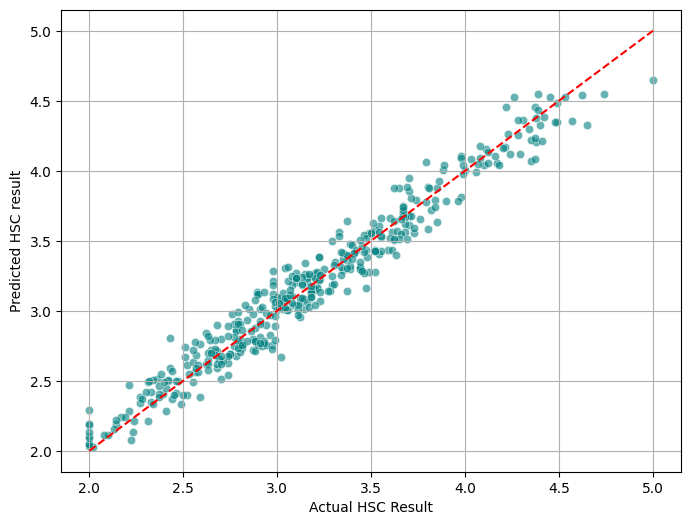